In [52]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys, os, time, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('../parameter_scan'))

In [2]:
import cartopy

In [34]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from cariaco_obs import DEFAULT_CSV_PATH

SARDINE_CSV = "../DATA/processed/sardine_sau.csv"

# --- figure scaling (one-column; tweak to taste) -------------------------
FIG_W, FIG_H = 3.54, 5.0                                  # ≈ 90 mm single column
MARGINS = dict(left=0.15, right=0.97, top=0.95, bottom=0.08, hspace=0.10)

WINDOW = (pd.Timestamp('1996-01-01'), pd.Timestamp('2017-12-31'))
ERA_X  = [pd.Timestamp('2005-01-01'), pd.Timestamp('2014-01-01')]
ERA_LBL = [('pre', pd.Timestamp('2000-07-01')),
           ('post', pd.Timestamp('2009-07-01')),
           ('recovery', pd.Timestamp('2015-07-01'))]
C_ISO, C_MCS, C_ZOO, C_FISH = '#26456E', '#3A3A3A', '#E08214', '#1A1A1A'
UM_TICKS = [1, 2, 5, 10, 20, 40]

ERA_LBL = [('pre',      pd.Timestamp('2000-07-01'), '#2E86AB'),
           ('post',     pd.Timestamp('2009-07-01'), '#E07A5F'),
           ('recovery', pd.Timestamp('2015-07-01'), '#81B29A')]

def load_obs():     return pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
def load_sardine():
    f = pd.read_csv(SARDINE_CSV)
    f = f[(f.year >= WINDOW[0].year) & (f.year <= WINDOW[1].year)].copy()
    f['t'] = pd.to_datetime(f.year.astype(str) + '-07-01'); f['kt'] = f.sardinelandings / 1e3
    return f.sort_values('t')

def add_eras(ax, label=False):
    for x in ERA_X:
        ax.axvline(x, color='0.6', lw=0.8, zorder=1)
    if label:
        for txt, t, c in ERA_LBL:
            ax.text(t, 0.93, txt, transform=ax.get_xaxis_transform(),
                    ha='center', va='top', fontsize=8, color=c, fontweight='bold', zorder=6,
                    path_effects=[pe.withStroke(linewidth=2, foreground='white')])

import matplotlib.patheffects as pe

def plot_panel(ax, df, col, color, kind='monthly', connect=False,
               s=5, alpha=0.20, min_months=5):
    halo = [pe.withStroke(linewidth=3.0, foreground='white')]
    if kind == 'monthly':
        d = df.dropna(subset=['date', col]); base = d[col].mean()
        ax.scatter(d['date'], d[col], s=s, color=color, alpha=alpha, lw=0, zorder=2)
        grp = d.assign(yr=d['date'].dt.year).groupby('yr')[col]
        ann = grp.mean()[grp.size() >= min_months]; years = list(ann.index)
    else:
        d = df.dropna(subset=['t', col]).sort_values('t'); base = d[col].mean()
        ann = d.set_index('year')[col]; years = list(ann.index)

    if connect:                                   # sardines: line + fill to the mean
        ann_t = pd.to_datetime([f'{int(y)}-07-01' for y in years])
        ax.fill_between(ann_t, base, ann.values, color=color, alpha=0.14, lw=0, zorder=3)
        ax.axhline(base, color='0.35', ls='--', lw=0.9, zorder=4)
        ax.plot(ann_t, ann.values, '-o', color=color, lw=1.2, ms=3.0,
                mec='white', mew=0.5, zorder=5, path_effects=halo)
    else:                                         # year bars + fill to the mean
        ax.axhline(base, color='0.35', ls='--', lw=0.9, zorder=4)
        for y in years:
            m = ann[y]
            t0 = pd.Timestamp(f'{int(y)}-01-01'); t1 = pd.Timestamp(f'{int(y)}-12-31')
            ax.fill_between([t0, t1], base, m, color=color, alpha=0.16, lw=0, zorder=3)
            ax.hlines(m, t0, t1, color=color, lw=1.8, zorder=5, path_effects=halo)
    return base

def panel_style(ax, ylabel, nbins=4):
    ax.set_ylabel(ylabel, fontsize=8)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=nbins))
    ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)

def xaxis_style(ax):
    ax.set_xlim(*WINDOW)
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_minor_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlabel('Year', fontsize=8)

In [43]:
def plot_panel_anom(ax, df, col, color, min_months=3, full_at=6):
    """Deseasonalised annual-mean anomalies: remove monthly climatology, year
       bars of the mean anomaly (faint for 3-5 month years), fill to zero."""
    halo = [pe.withStroke(linewidth=3.0, foreground='white')]
    d = df.dropna(subset=['date', col]).copy()
    d['yr'] = d['date'].dt.year; d['mo'] = d['date'].dt.month
    d['anom'] = d[col] - d.groupby('mo')[col].transform('mean')
    ax.scatter(d['date'], d['anom'], s=5, color=color, alpha=0.18, lw=0, zorder=2)
    g = d.groupby('yr'); n = g['anom'].size(); ann = g['anom'].mean()
    ax.axhline(0, color='0.35', ls='--', lw=0.9, zorder=4)
    for y in n[n >= min_months].index:
        m = ann[y]; thin = n[y] < full_at
        t0 = pd.Timestamp(f'{int(y)}-01-01'); t1 = pd.Timestamp(f'{int(y)}-12-31')
        ax.fill_between([t0, t1], 0, m, color=color, alpha=0.07 if thin else 0.16, lw=0, zorder=3)
        ax.hlines(m, t0, t1, color=color, lw=1.3 if thin else 1.9,
                  alpha=0.45 if thin else 1.0, zorder=5, path_effects=halo)

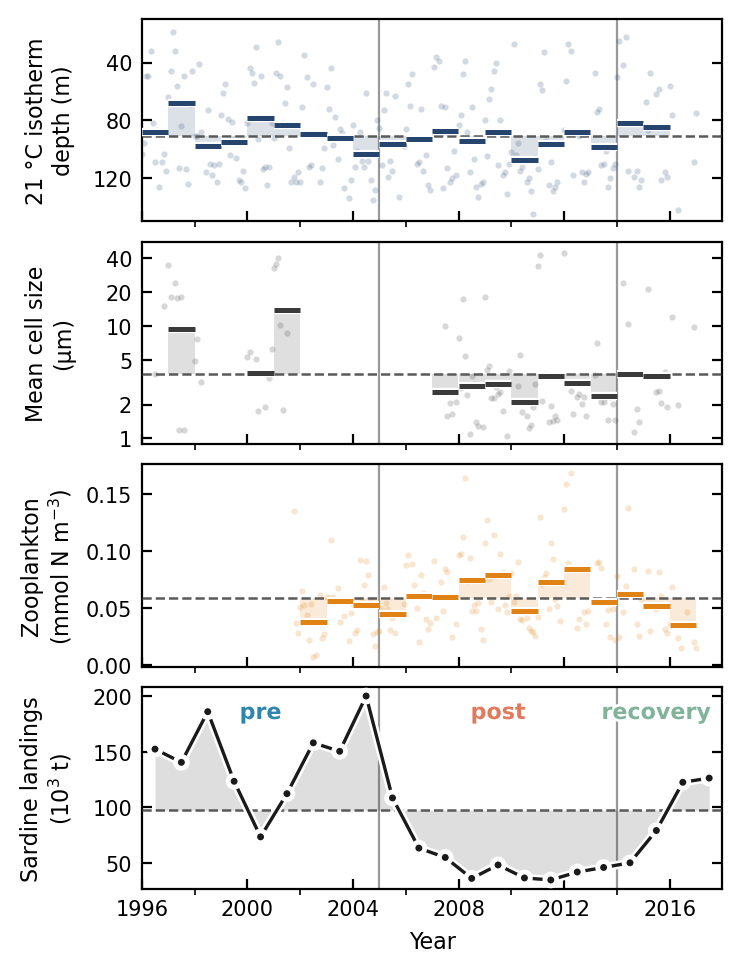

In [35]:
obs, fish = load_obs(), load_sardine()
fig, (axI, axM, axZ, axF) = plt.subplots(4, 1, figsize=(FIG_W, FIG_H), sharex=True)
fig.subplots_adjust(**MARGINS)

for ax in (axI, axM, axZ, axF):
    add_eras(ax, label=(ax is axF))

plot_panel(axI, obs, 'Isotherm_21', C_ISO)
panel_style(axI, '21 °C isotherm\ndepth (m)'); axI.set_ylim(150, 10)

plot_panel(axM, obs, 'size_centroid', C_MCS)
panel_style(axM, 'Mean cell size\n(µm)')
axM.set_yticks([np.log10(u) for u in UM_TICKS]); axM.set_yticklabels(UM_TICKS); axM.set_ylim(-0.05, 1.75)

plot_panel(axZ, obs, 'zoo_gt200_mmolN', C_ZOO)
panel_style(axZ, 'Zooplankton\n(mmol N m$^{-3}$)')

plot_panel(axF, fish, 'kt', C_FISH, kind='annual', connect=True)   # sardines: connected line
panel_style(axF, 'Sardine landings\n(10$^3$ t)')

xaxis_style(axF)
for ax in (axI, axM, axZ):
    ax.tick_params(labelbottom=False); ax.set_xlabel('')
fig.align_ylabels((axI, axM, axZ, axF))
plt.show()

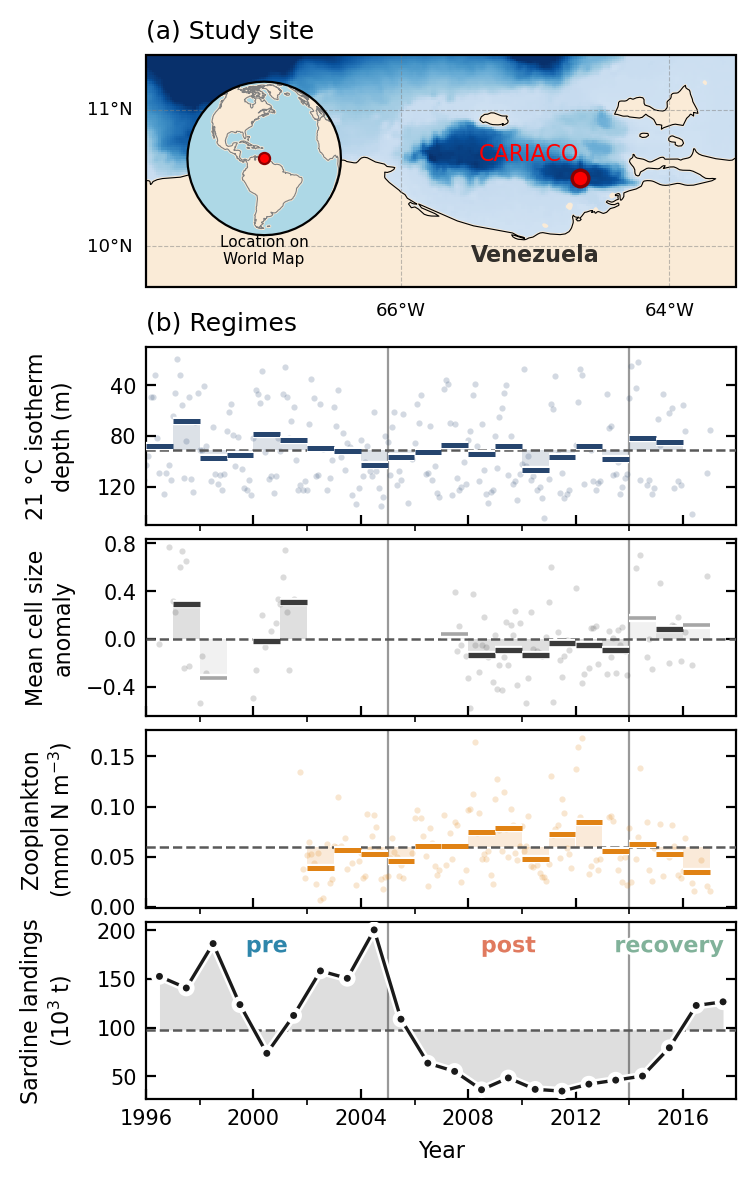

In [51]:
%config InlineBackend.figure_format = 'retina'      # or 'svg' for the crispest text
# =====================================================================
# Figure 1 — map (a) + stack (b)   [no colorbar, manual layout]
# Requires Cell 1 helpers (plot_panel, add_eras, panel_style, xaxis_style,
# loaders, C_* / UM_TICKS).
# =====================================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
import pygmt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

lon_min, lon_max = -67.9, -63.5
lat_min, lat_max = 9.7, 11.4
region = [lon_min, lon_max, lat_min, lat_max]
mooring_lon, mooring_lat = -64.67, 10.5

def load_bathymetry(region):
    grid = pygmt.datasets.load_earth_relief(resolution="01m", region=region)
    return pygmt.grdclip(grid, above=[0, 0])

def draw_cariaco_map(ax, grid):
    base = plt.get_cmap("Blues_r")
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "Blues_r_deep", base(np.linspace(0.0, 0.80, 256)))
    norm = mcolors.Normalize(vmin=-1500, vmax=0)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.set_aspect('auto')
    grid.plot.pcolormesh(ax=ax, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),
                         zorder=0, add_colorbar=False)
    ax.add_feature(cfeature.LAND, color='antiquewhite', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor='black', zorder=2)   # land outline

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5,
                      linestyle='--', zorder=3)
    gl.top_labels = gl.right_labels = False
    gl.xlocator = mticker.FixedLocator([-66, -64]); gl.ylocator = mticker.FixedLocator([10, 11])
    gl.xformatter = LONGITUDE_FORMATTER; gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 6.5}; gl.ylabel_style = {'size': 6.5}

    ax.text(-65.0, 9.85, 'Venezuela', fontsize=8, color='black', weight='bold',
            ha='center', va='bottom', alpha=0.8, transform=ccrs.PlateCarree(), zorder=5)
    ax.plot(mooring_lon, mooring_lat, 'o', color='red', markersize=6,
            markeredgecolor='darkred', markeredgewidth=1.2,
            transform=ccrs.PlateCarree(), zorder=10)
    ax.text(mooring_lon, mooring_lat + 0.09, 'CARIACO', fontsize=8,
            color='red', ha='right', va='bottom', transform=ccrs.PlateCarree(), zorder=10)

    # world-locator inset: square globe (fills its box) + caption, top-left
    asp = (lon_max - lon_min) * np.cos(np.radians(0.5*(lat_min+lat_max))) / (lat_max - lat_min)
    gw  = 0.26; gh = gw * asp; cap = 0.11                      # gw = globe size dial
    
    bw, bh = gw + 0.02, gh + cap
    bx, by = 0.06, (1.0 - bh) / 2
    
    #ax.add_patch(mpatches.Rectangle((bx, by), bw, bh, facecolor='white',
    #             edgecolor='black', linewidth=0.8, transform=ax.transAxes, zorder=11))
    axi = ax.inset_axes([bx + 0.01, by + cap, gw, gh],
                        projection=ccrs.Orthographic(mooring_lon, mooring_lat), zorder=12)
    axi.set_global()
    axi.add_feature(cfeature.OCEAN, color='lightblue', zorder=0)
    axi.add_feature(cfeature.LAND, color='antiquewhite', zorder=1)
    axi.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor='grey', zorder=2)
    axi.plot(mooring_lon, mooring_lat, 'o', color='red', markersize=4,
             markeredgecolor='darkred', markeredgewidth=0.8, transform=ccrs.PlateCarree(), zorder=13)
    ax.text(bx + bw/2, by + cap*0.5-0.01, 'Location on\nWorld Map', ha='center', va='center',
            fontsize=5.5, color='black', transform=ax.transAxes, zorder=13)

# --- assemble ------------------------------------------------------------
obs, fish = load_obs(), load_sardine()
grid = load_bathymetry(region)

LEFT, RIGHT, TOPM, BOT, GAP, HSP = 0.15, 0.97, 0.95, 0.08, 0.05, 0.08
FIG_W, FIG_H = 3.6, 6.0

lat_mid   = 0.5 * (lat_min + lat_max)
aspect_wh = (lon_max - lon_min) * np.cos(np.radians(lat_mid)) / (lat_max - lat_min)
map_h_fr  = ((RIGHT - LEFT) * FIG_W / aspect_wh) / FIG_H        # map height that avoids stretch
map_bot   = TOPM - map_h_fr
ts_top    = map_bot - GAP

fig = plt.figure(figsize=(FIG_W, FIG_H))
gs_map = fig.add_gridspec(1, 1, left=LEFT, right=RIGHT, top=TOPM, bottom=map_bot)
ax_map = fig.add_subplot(gs_map[0], projection=ccrs.PlateCarree())
draw_cariaco_map(ax_map, grid)
ax_map.set_title('(a) Study site', loc='left', fontsize=9)

gs_ts = fig.add_gridspec(4, 1, left=LEFT, right=RIGHT, top=ts_top, bottom=BOT, hspace=HSP)
axI = fig.add_subplot(gs_ts[0]); axM = fig.add_subplot(gs_ts[1], sharex=axI)
axZ = fig.add_subplot(gs_ts[2], sharex=axI); axF = fig.add_subplot(gs_ts[3], sharex=axI)
axI.set_title('(b) Regimes', loc='left', fontsize=9)

for ax in (axI, axM, axZ, axF):
    add_eras(ax, label=(ax is axF))
plot_panel(axI, obs, 'Isotherm_21', C_ISO); panel_style(axI, '21 °C isotherm\ndepth (m)'); axI.set_ylim(150, 10)

#plot_panel(axM, obs, 'size_centroid', C_MCS); panel_style(axM, 'Mean cell size\n(µm)')
#axM.set_yticks([np.log10(u) for u in UM_TICKS]); axM.set_yticklabels(UM_TICKS); axM.set_ylim(-0.05, 1.75)
plot_panel_anom(axM, obs, 'size_centroid', C_MCS); panel_style(axM, 'Mean cell size\nanomaly')

plot_panel(axZ, obs, 'zoo_gt200_mmolN', C_ZOO); panel_style(axZ, 'Zooplankton\n(mmol N m$^{-3}$)')
plot_panel(axF, fish, 'kt', C_FISH, kind='annual', connect=True); panel_style(axF, 'Sardine landings\n(10$^3$ t)')

xaxis_style(axF)
for ax in (axI, axM, axZ):
    ax.tick_params(labelbottom=False); ax.set_xlabel('')
fig.align_ylabels((axI, axM, axZ, axF))
plt.show()

In [33]:
import pandas as pd
from cariaco_obs import DEFAULT_CSV_PATH

d = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date']).dropna(subset=['size_centroid'])
d['yr'] = d['date'].dt.year
cov = (d.groupby('yr')['size_centroid']
         .agg(n_months='size', ann_mean='mean').round(3).reset_index())
cov['bar_drawn'] = cov['n_months'] >= 6
print(cov.to_string(index=False))
print(f"\n{len(cov)} years with MCS data | "
      f"{(cov.n_months >= 6).sum()} pass the >=6-month gate, "
      f"{(cov.n_months < 6).sum()} fall short")

  yr  n_months  ann_mean  bar_drawn
1996         2     0.873      False
1997         7     0.977       True
1998         3     0.689      False
2000         7     0.581       True
2001         6     1.146       True
2007         5     0.411      False
2008        11     0.467       True
2009        12     0.488       True
2010         9     0.327       True
2011         9     0.558       True
2012         8     0.490       True
2013        10     0.380       True
2014         5     0.574      False
2015         6     0.558       True
2016         3     0.789      False

15 years with MCS data | 10 pass the >=6-month gate, 5 fall short


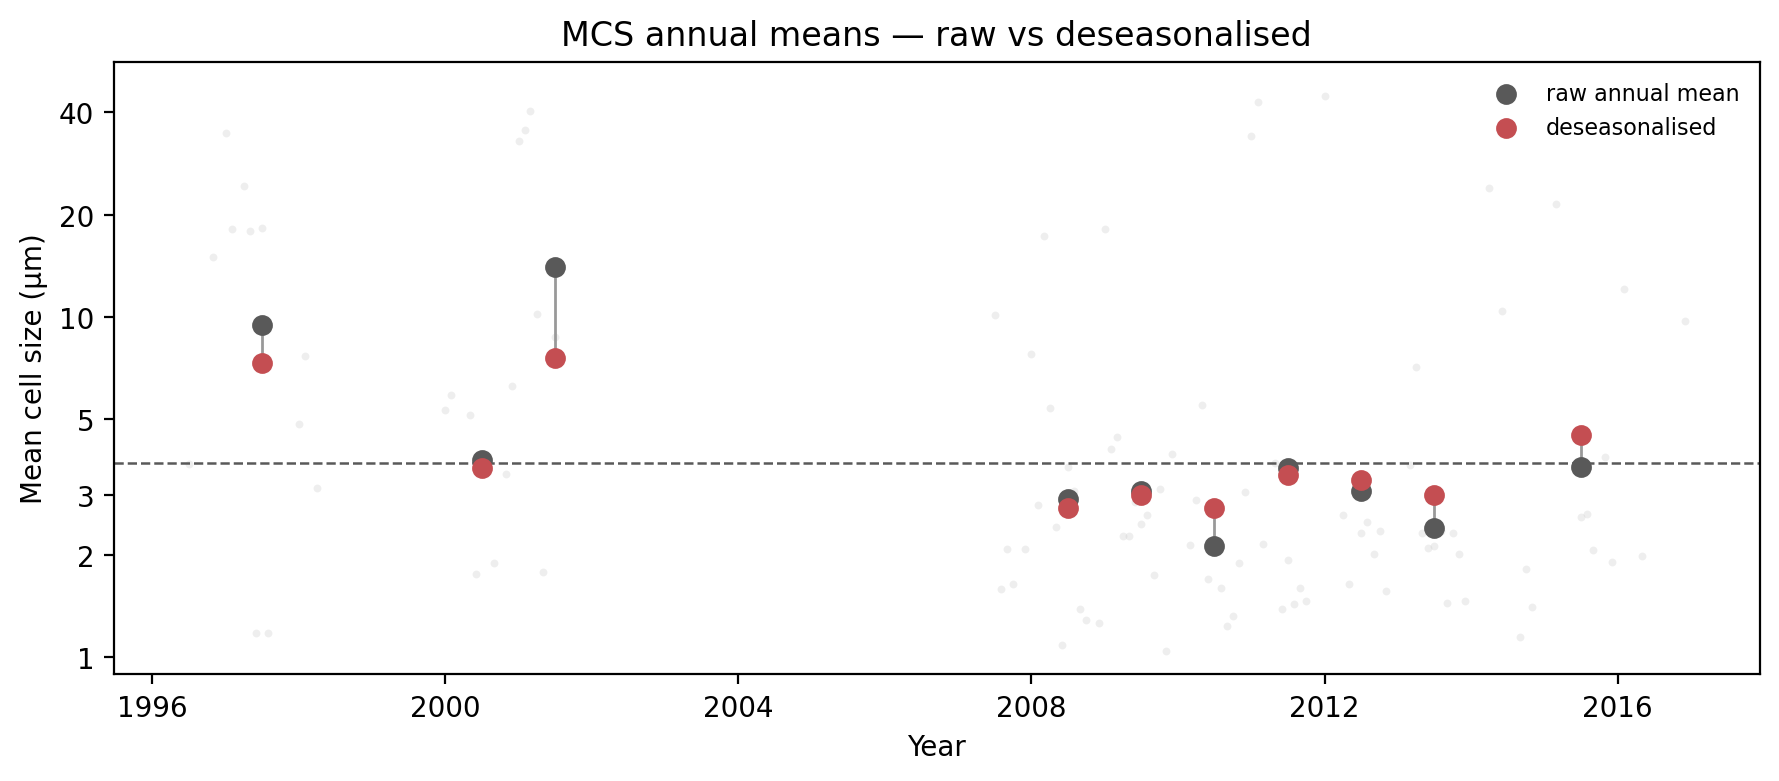

      n_months    raw  deseason  shift
yr                                    
1997         7  0.977     0.865 -0.112
2000         7  0.581     0.557 -0.024
2001         6  1.146     0.879 -0.267
2008        11  0.467     0.439 -0.028
2009        12  0.488     0.476 -0.011
2010         9  0.327     0.440  0.113
2011         9  0.558     0.536 -0.021
2012         8  0.490     0.521  0.031
2013        10  0.380     0.477  0.097
2015         6  0.558     0.653  0.094

mean |shift| = 0.080 centroid units (~×1.20 in µm)


In [37]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from cariaco_obs import DEFAULT_CSV_PATH

col = 'size_centroid'
d = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date']).dropna(subset=[col]).copy()
d['yr'] = d['date'].dt.year; d['mo'] = d['date'].dt.month

grand = d[col].mean()
d['anom'] = d[col] - d.groupby('mo')[col].transform('mean')   # remove monthly climatology
g = d.groupby('yr')
n   = g[col].size()
raw = g[col].mean()
des = grand + g['anom'].mean()                                # deseasonalised, native units
keep = n[n >= 6].index
raw, des = raw.loc[keep], des.loc[keep]
t = pd.to_datetime([f'{y}-07-01' for y in keep])

UM = [1, 2, 3, 5, 10, 20, 40]
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(d['date'], d[col], s=8, color='0.75', alpha=0.25, lw=0, zorder=1)
ax.vlines(t, raw.values, des.values, color='0.6', lw=1.0, zorder=2)
ax.scatter(t, raw.values, s=42, color='0.35',   label='raw annual mean', zorder=3)
ax.scatter(t, des.values, s=42, color='#C44E52', label='deseasonalised', zorder=3)
ax.axhline(grand, color='0.35', ls='--', lw=0.9)
ax.set_yticks([np.log10(u) for u in UM]); ax.set_yticklabels(UM); ax.set_ylim(-0.05, 1.75)
ax.set_ylabel('Mean cell size (µm)'); ax.set_xlabel('Year')
ax.legend(fontsize=8, frameon=False)
ax.set_title('MCS annual means — raw vs deseasonalised')
plt.tight_layout(); plt.show()

shift = des - raw
print(pd.DataFrame({'n_months': n.loc[keep], 'raw': raw.round(3),
                    'deseason': des.round(3), 'shift': shift.round(3)}).to_string())
print(f"\nmean |shift| = {shift.abs().mean():.3f} centroid units "
      f"(~×{10**shift.abs().mean():.2f} in µm)")

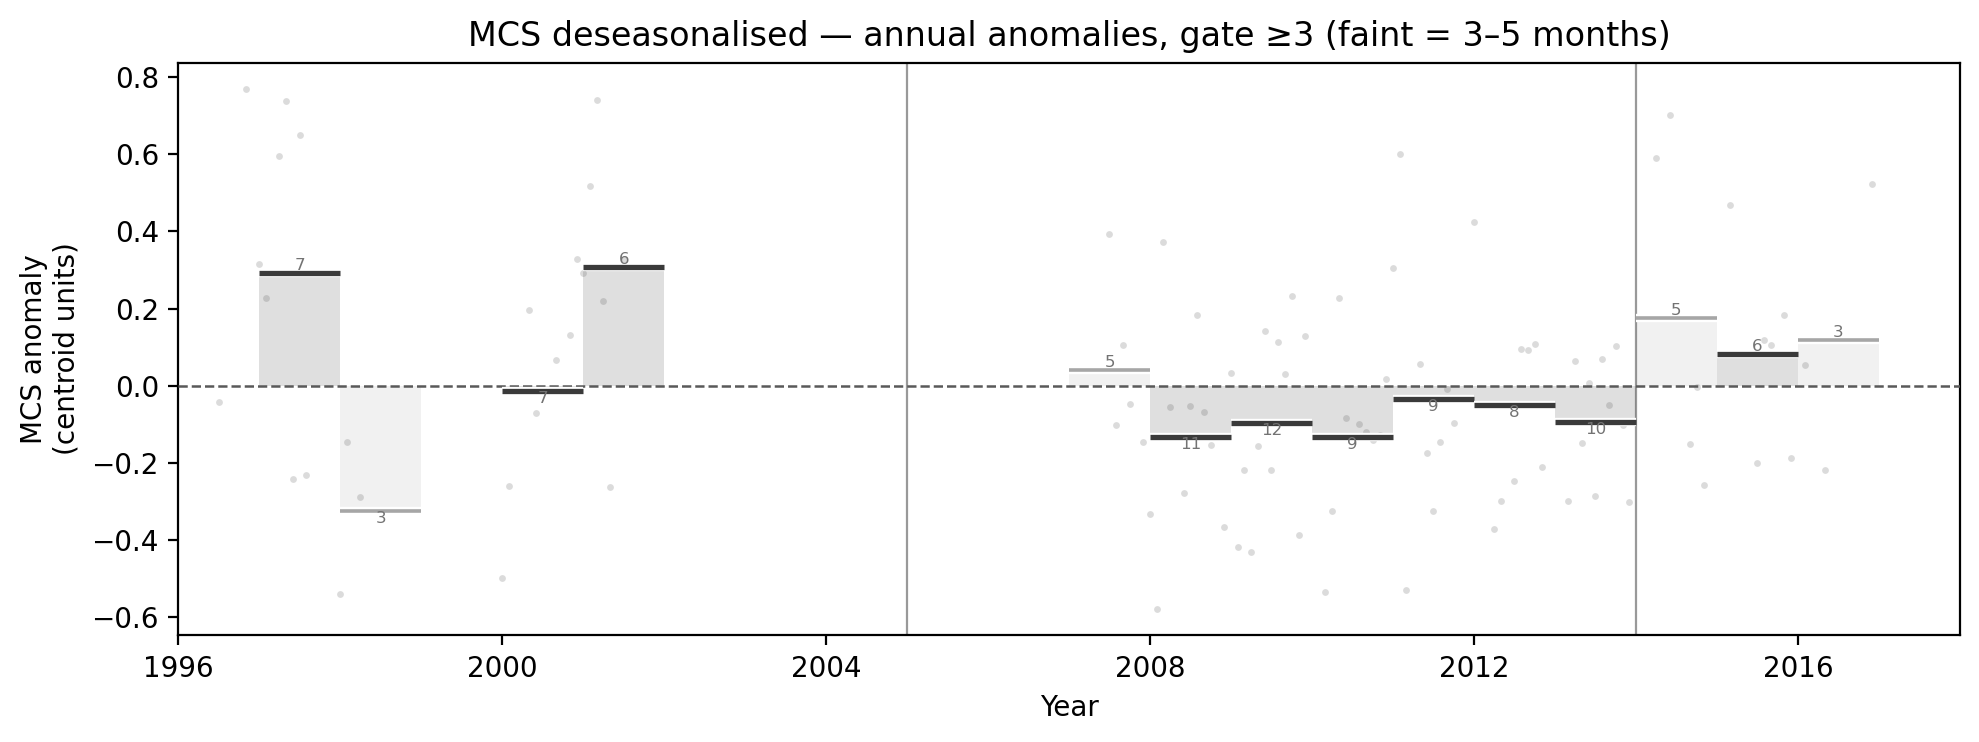

      n_months  anom_mean shown_as
yr                                
1997         7      0.293     full
1998         3     -0.325     thin
2000         7     -0.015     full
2001         6      0.307     full
2007         5      0.040     thin
2008        11     -0.133     full
2009        12     -0.096     full
2010         9     -0.132     full
2011         9     -0.035     full
2012         8     -0.051     full
2013        10     -0.095     full
2014         5      0.177     thin
2015         6      0.081     full
2016         3      0.119     thin


In [42]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from cariaco_obs import DEFAULT_CSV_PATH

col, GATE, COL = 'size_centroid', 3, '#3A3A3A'
d = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date']).dropna(subset=[col]).copy()
d['yr'] = d['date'].dt.year; d['mo'] = d['date'].dt.month
d['anom'] = d[col] - d.groupby('mo')[col].transform('mean')      # deseasonalised

g = d.groupby('yr'); n = g['anom'].size(); ann = g['anom'].mean()
keep = n[n >= GATE].index
halo = [pe.withStroke(linewidth=3.0, foreground='white')]

fig, ax = plt.subplots(figsize=(10, 3.8))
for x in (pd.Timestamp('2005-01-01'), pd.Timestamp('2014-01-01')):
    ax.axvline(x, color='0.6', lw=0.8, zorder=1)
ax.axhline(0, color='0.35', ls='--', lw=0.9, zorder=4)
ax.scatter(d['date'], d['anom'], s=6, color=COL, alpha=0.18, lw=0, zorder=2)
for y in keep:
    m = ann[y]; thin = n[y] < 6
    t0 = pd.Timestamp(f'{int(y)}-01-01'); t1 = pd.Timestamp(f'{int(y)}-12-31')
    ax.fill_between([t0, t1], 0, m, color=COL, alpha=0.07 if thin else 0.16, lw=0, zorder=3)
    ax.hlines(m, t0, t1, color=COL, lw=1.3 if thin else 1.9,
              alpha=0.45 if thin else 1.0, zorder=5, path_effects=halo)
    ax.text(t0 + (t1 - t0) / 2, m, f'{n[y]}', fontsize=6, color='0.45',
            ha='center', va='bottom' if m >= 0 else 'top', zorder=6)
ax.set_ylabel('MCS anomaly\n(centroid units)'); ax.set_xlabel('Year')
ax.set_xlim(pd.Timestamp('1996-01-01'), pd.Timestamp('2017-12-31'))
ax.set_title(f'MCS deseasonalised — annual anomalies, gate ≥{GATE} (faint = 3–5 months)')
plt.tight_layout(); plt.show()

print(pd.DataFrame({'n_months': n.loc[keep], 'anom_mean': ann.loc[keep].round(3),
                    'shown_as': np.where(n.loc[keep] < 6, 'thin', 'full')}).to_string())

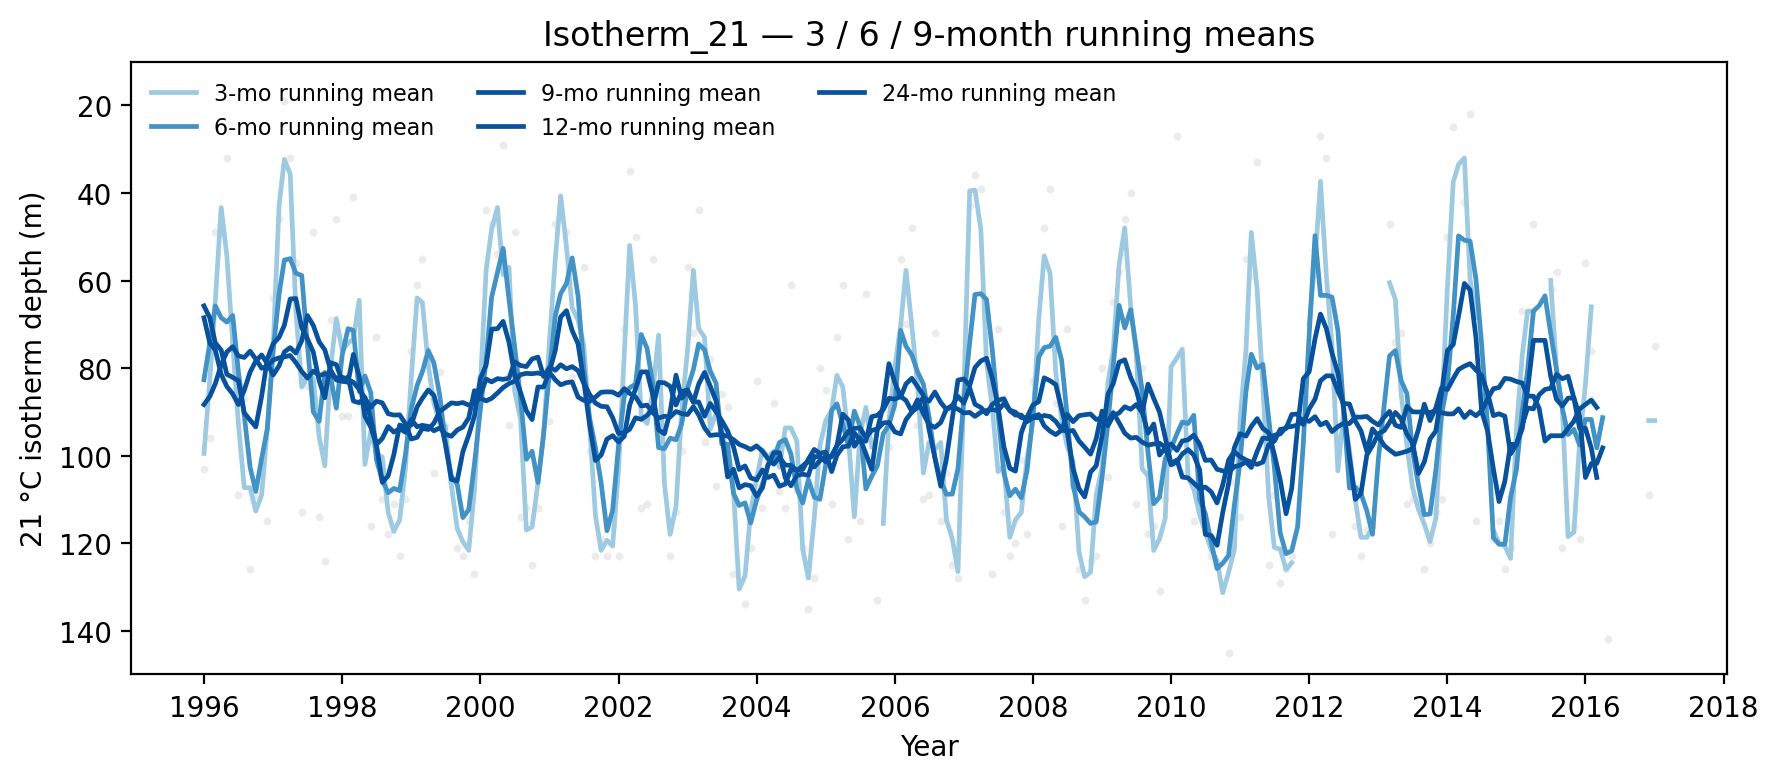

In [41]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from cariaco_obs import DEFAULT_CSV_PATH

col = 'Isotherm_21'
d = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date']).dropna(subset=[col])
full = pd.date_range('1996-01-01', '2017-12-01', freq='MS')
s = d.set_index('date')[col]; s = s[~s.index.duplicated()].reindex(full)

windows = [(3, '#9ecae1'), (6, '#4292c6'), (9, '#08519c'), (12, '#08519c'), (24, '#08519c')]
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(s.index, s.values, s=8, color='0.75', alpha=0.30, lw=0, zorder=1)
for w, c in windows:
    rm = s.rolling(w, center=True, min_periods=max(2, w // 2)).mean()
    ax.plot(s.index, rm, '-', color=c, lw=1.7, label=f'{w}-mo running mean', zorder=3)
ax.set_ylim(150, 10)
ax.set_ylabel('21 °C isotherm depth (m)'); ax.set_xlabel('Year')
ax.xaxis.set_major_locator(mdates.YearLocator(2)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=8, frameon=False, ncol=3)
ax.set_title('Isotherm_21 — 3 / 6 / 9-month running means')
plt.tight_layout(); plt.show()

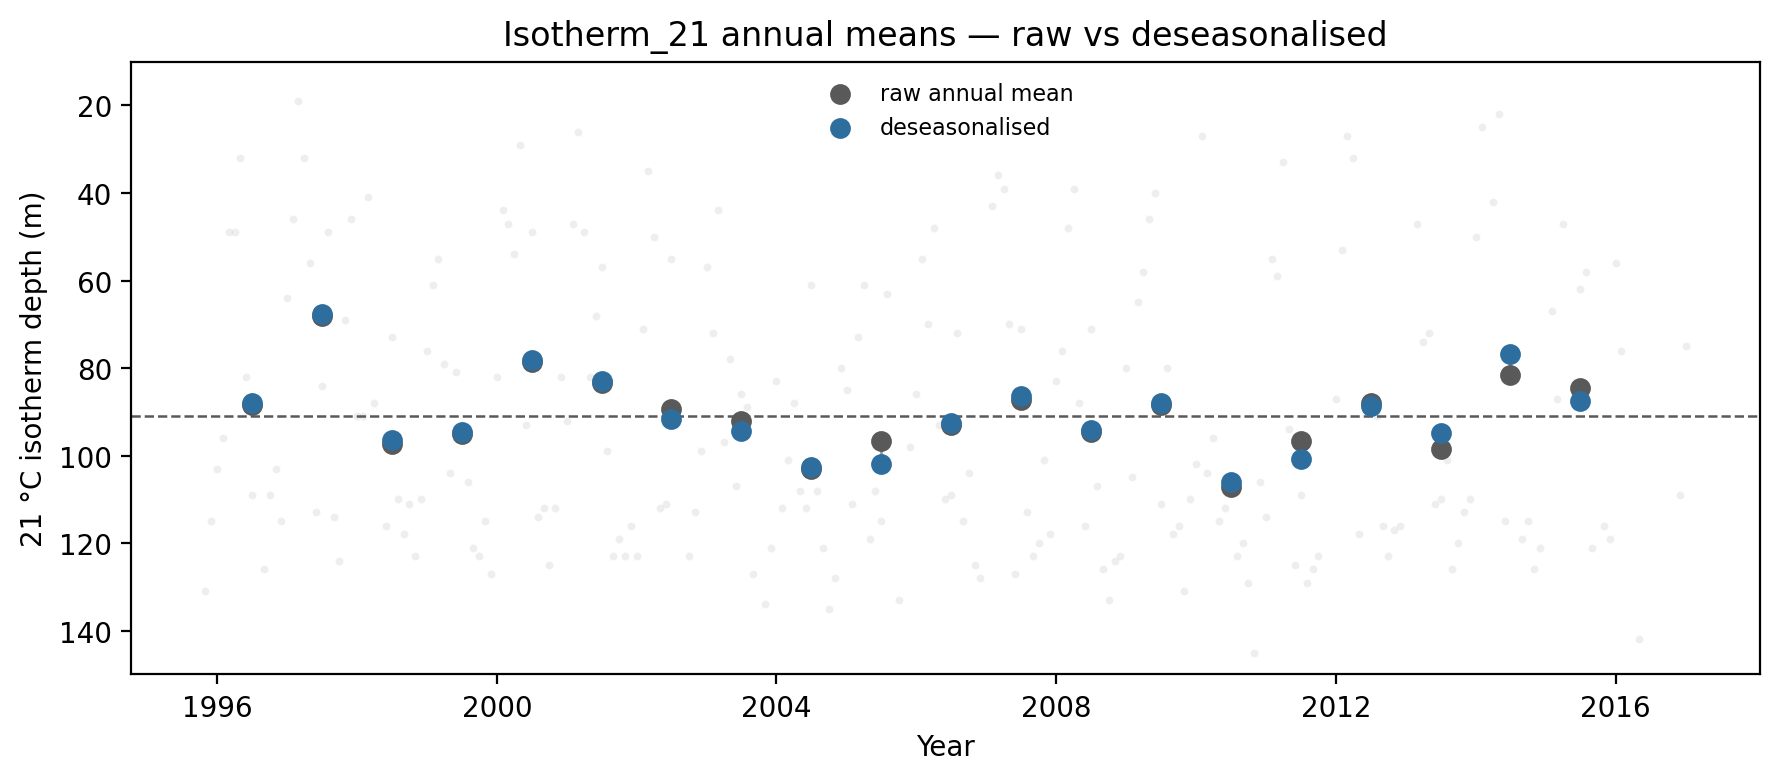

      n_months    raw  deseason  shift
yr                                    
1996        12   88.3      87.9   -0.4
1997        12   68.0      67.6   -0.4
1998        11   97.5      96.3   -1.1
1999        12   95.1      94.7   -0.4
2000        12   78.6      78.2   -0.4
2001        12   83.4      83.0   -0.4
2002        11   89.3      91.6    2.3
2003        11   92.0      94.4    2.4
2004        12  103.1     102.7   -0.4
2005        10   96.6     101.9    5.3
2006        12   92.9      92.5   -0.4
2007        11   87.4      86.3   -1.1
2008        12   94.5      94.1   -0.4
2009        12   88.3      87.9   -0.4
2010        11  107.2     106.1   -1.0
2011        10   96.7     100.7    4.0
2012        11   88.1      88.7    0.6
2013        10   98.4      94.8   -3.6
2014         9   81.7      76.7   -5.0
2015         8   84.6      87.5    2.8

mean |shift| = 1.6 m


In [38]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from cariaco_obs import DEFAULT_CSV_PATH

col = 'Isotherm_21'
d = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date']).dropna(subset=[col]).copy()
d['yr'] = d['date'].dt.year; d['mo'] = d['date'].dt.month

grand = d[col].mean()
d['anom'] = d[col] - d.groupby('mo')[col].transform('mean')
g = d.groupby('yr')
n   = g[col].size()
raw = g[col].mean()
des = grand + g['anom'].mean()
keep = n[n >= 6].index
raw, des = raw.loc[keep], des.loc[keep]
t = pd.to_datetime([f'{y}-07-01' for y in keep])

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(d['date'], d[col], s=8, color='0.75', alpha=0.25, lw=0, zorder=1)
ax.vlines(t, raw.values, des.values, color='0.6', lw=1.0, zorder=2)
ax.scatter(t, raw.values, s=42, color='0.35',   label='raw annual mean', zorder=3)
ax.scatter(t, des.values, s=42, color='#2E6E9E', label='deseasonalised', zorder=3)
ax.axhline(grand, color='0.35', ls='--', lw=0.9)
ax.set_ylim(150, 10)
ax.set_ylabel('21 °C isotherm depth (m)'); ax.set_xlabel('Year')
ax.legend(fontsize=8, frameon=False)
ax.set_title('Isotherm_21 annual means — raw vs deseasonalised')
plt.tight_layout(); plt.show()

shift = des - raw
print(pd.DataFrame({'n_months': n.loc[keep], 'raw': raw.round(1),
                    'deseason': des.round(1), 'shift': shift.round(1)}).to_string())
print(f"\nmean |shift| = {shift.abs().mean():.1f} m")

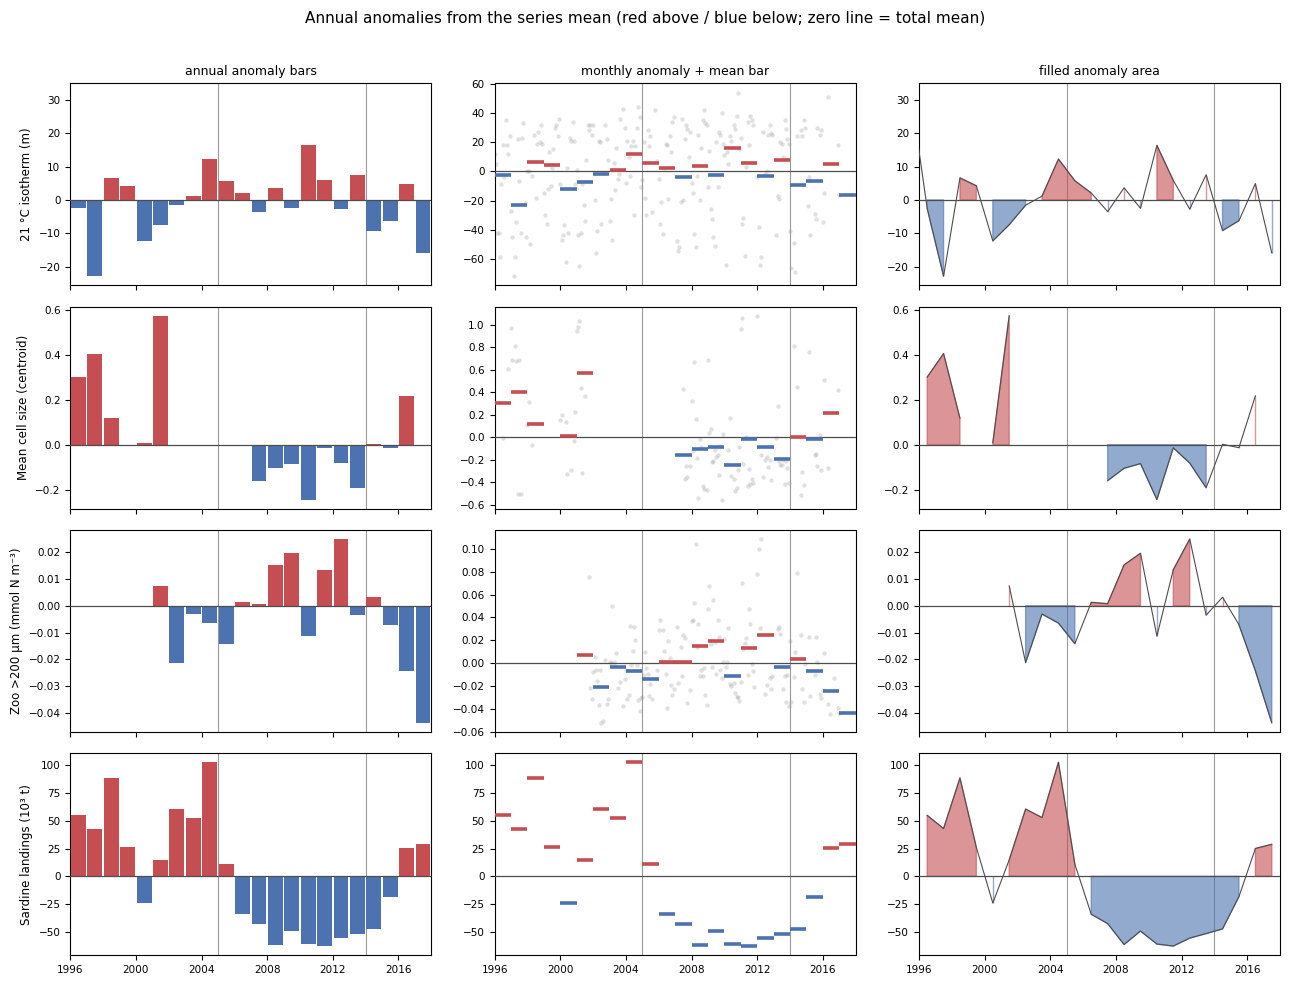

In [8]:
# =====================================================================
# Anomaly-from-total-mean — test strip (rows: series, cols: render style)
# =====================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from cariaco_obs import DEFAULT_CSV_PATH

SARDINE_CSV = "../DATA/processed/sardine_sau.csv"
WINDOW = (pd.Timestamp('1996-01-01'), pd.Timestamp('2017-12-31'))
ERA_X  = [pd.Timestamp('2005-01-01'), pd.Timestamp('2014-01-01')]
POS, NEG = '#C44E52', '#4C72B0'

obs = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
fish = pd.read_csv(SARDINE_CSV)
fish = fish[(fish.year >= 1996) & (fish.year <= 2017)].copy()
fish['t'] = pd.to_datetime(fish.year.astype(str) + '-07-01'); fish['kt'] = fish.sardinelandings / 1e3

def series_data(df, col, kind):
    if kind == 'monthly':
        d = df.dropna(subset=['date', col]).copy(); d['yr'] = d['date'].dt.year
        return d, d[col].mean(), d.groupby('yr')[col].mean()
    d = df.dropna(subset=['t', col]).copy()
    return None, d[col].mean(), d.set_index('year')[col]

def render_bars(ax, base, ann):
    t = pd.to_datetime([f'{y}-07-01' for y in ann.index]); a = ann.values - base
    ax.bar(t, a, width=330, align='center',
           color=[POS if v >= 0 else NEG for v in a], zorder=3)
    ax.axhline(0, color='0.3', lw=0.9, zorder=4)

def render_scatter_bars(ax, base, ann, d, col):
    if d is not None:
        ax.scatter(d['date'], d[col] - base, s=10, color='0.6', alpha=0.30, lw=0, zorder=2)
    for y, v in (ann - base).items():
        ax.hlines(v, pd.Timestamp(f'{y}-01-01'), pd.Timestamp(f'{y}-12-31'),
                  color=POS if v >= 0 else NEG, lw=2.6, zorder=4)
    ax.axhline(0, color='0.3', lw=0.9, zorder=3)

def render_fill(ax, base, ann):
    yrs = np.arange(int(ann.index.min()), int(ann.index.max()) + 1)
    a = (ann.reindex(yrs) - base).values
    t = pd.to_datetime([f'{y}-07-01' for y in yrs])
    ax.fill_between(t, 0, a, where=a >= 0, color=POS, alpha=0.6, interpolate=False, zorder=2)
    ax.fill_between(t, 0, a, where=a < 0,  color=NEG, alpha=0.6, interpolate=False, zorder=2)
    ax.plot(t, a, '-', color='0.3', lw=0.8, zorder=3)
    ax.axhline(0, color='0.3', lw=0.9, zorder=4)

VARS = [
    ('21 °C isotherm (m)',         obs,  'Isotherm_21',     'monthly'),
    ('Mean cell size (centroid)',  obs,  'size_centroid',   'monthly'),
    ('Zoo >200 µm (mmol N m⁻³)',   obs,  'zoo_gt200_mmolN', 'monthly'),
    ('Sardine landings (10³ t)',   fish, 'kt',              'annual'),
]
COLS = ['annual anomaly bars', 'monthly anomaly + mean bar', 'filled anomaly area']

fig, axs = plt.subplots(len(VARS), 3, figsize=(13, 10), squeeze=False)
for i, (lab, src, col, kind) in enumerate(VARS):
    d, base, ann = series_data(src, col, kind)
    for j in range(3):
        ax = axs[i, j]
        for x in ERA_X: ax.axvline(x, color='0.6', lw=0.8, zorder=1)
        if   j == 0: render_bars(ax, base, ann)
        elif j == 1: render_scatter_bars(ax, base, ann, d, col)
        else:        render_fill(ax, base, ann)
        ax.set_xlim(*WINDOW); ax.tick_params(labelsize=7.5)
        if i == 0: ax.set_title(COLS[j], fontsize=9)
        if j == 0: ax.set_ylabel(lab, fontsize=8.5)
        if i < len(VARS) - 1:
            ax.tick_params(labelbottom=False)
        else:
            ax.xaxis.set_major_locator(mdates.YearLocator(4)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('Annual anomalies from the series mean (red above / blue below; zero line = total mean)', fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()